# Hands-On Module 2: Mathematical Foundation and Data Visualization for AI

MPG dataset EDA, statistics, and visualisation using NumPy, Pandas, Seaborn, and Matplotlib.

# Stage 1: Inspection and Data Cleaning

## Load the dataset and inspect shape, dtypes, and missing values

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

Shape: (398, 9)

Dtypes:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


Only `horsepower` has missing values, 6 rows out of 398 (about 1.5% of the dataset).


In [2]:
df[df['horsepower'].isna()]

**Missing value strategy: drop the 6 rows.**

* 6 out of 398 rows is about 1.5% of the data. Dropping them barely changes sample size or the distribution of any other column.
* The missing rows are spread across different `model_year` values (71, 74, 80, 81, 82) and both `usa` and `europe` origins. There is no visible pattern suggesting the missingness depends on another column, so it looks closer to missing completely at random than missing for a systematic reason.
* `horsepower` is one of the five core numeric features used throughout this analysis (z-score standardisation, correlation matrix, PCA). Imputing it (for example with the column mean) would artificially shrink its variance and could distort the correlation and PCA results computed later.
* Given the small proportion of affected rows and the risk of a biased imputation affecting downstream statistics, dropping is the safer and simpler choice here.


In [3]:
df = df.dropna(subset=['horsepower']).reset_index(drop=True)
print("Shape after dropping missing horsepower rows:", df.shape)

Shape after dropping missing horsepower rows: (392, 9)


## Summary table using NumPy (mean, median, std, IQR, outlier count)

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

def summarize_numeric(data: pd.DataFrame, columns: list) -> pd.DataFrame:
    rows = []
    for col in columns:
        arr = data[col].to_numpy()
        q1, q3 = np.percentile(arr, [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_count = int(((arr < lo) | (arr > hi)).sum())
        rows.append({
            'column': col,
            'mean': arr.mean(),
            'median': np.median(arr),
            'std': arr.std(ddof=1),
            'iqr': iqr,
            'outlier_count': outlier_count
        })
    return pd.DataFrame(rows)

summary_df = summarize_numeric(df, numeric_cols)
print(summary_df.round(3).to_string(index=False))

Numeric columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
      column     mean  median     std     iqr  outlier_count
         mpg   23.446   22.75   7.805   12.00              0
   cylinders    5.472    4.00   1.706    4.00              0
displacement  194.412  151.00 104.644  170.75              0
  horsepower  104.469   93.50  38.491   51.00             10
      weight 2977.584 2803.50 849.403 1389.50              0
acceleration   15.541   15.50   2.759    3.25             11
  model_year   75.980   76.00   3.684    6.00              0


* `horsepower` and `acceleration` are the only columns with IQR-based outliers, 10 and 11 respectively.
* `horsepower` outliers are almost certainly genuine high-performance engines rather than data entry errors, since horsepower values above roughly 190 are physically plausible for the muscle cars/trucks common in this dataset's era.
* `weight`, `displacement`, and `cylinders` have wide IQRs relative to their scale, consistent with the dataset mixing small economy cars and large sedans/trucks.


# Stage 2: Statistical Analysis with NumPy

## Extract features and apply z-score standardisation

In [5]:
feature_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
feature_array = df[feature_cols].to_numpy()

def zscore_standardize(arr: np.ndarray) -> np.ndarray:
    col_mean = arr.mean(axis=0)
    col_std = arr.std(axis=0, ddof=1)
    return (arr - col_mean) / col_std

z_array = zscore_standardize(feature_array)

print("feature_array shape:", feature_array.shape)
print("z-scored mean per column (should be ~0):", z_array.mean(axis=0).round(10))
print("z-scored std per column (should be ~1):", z_array.std(axis=0, ddof=1).round(10))

feature_array shape: (392, 5)
z-scored mean per column (should be ~0): [ 0. -0. -0.  0.  0.]
z-scored std per column (should be ~1): [1. 1. 1. 1. 1.]


Standardisation is fully vectorised.

* `arr.mean(axis=0)` and `arr.std(axis=0, ddof=1)` compute per-column statistics for the whole array at once.
* No explicit Python loop is used, and no `sklearn.StandardScaler` is used.
* `ddof=1` is used for std so this matches Pandas' default (sample standard deviation, dividing by n minus 1) rather than NumPy's population default.


## Correlation matrix of the five features

In [6]:
corr_matrix = np.corrcoef(feature_array, rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=feature_cols, columns=feature_cols)
print(corr_df.round(3))

                mpg  displacement  horsepower  weight  acceleration
mpg           1.000        -0.805      -0.778  -0.832         0.423
displacement -0.805         1.000       0.897   0.933        -0.544
horsepower   -0.778         0.897       1.000   0.865        -0.689
weight       -0.832         0.933       0.865   1.000        -0.417
acceleration  0.423        -0.544      -0.689  -0.417         1.000


In [7]:
n = len(feature_cols)
mask_offdiag = np.triu(~np.eye(n, dtype=bool))
corr_masked = np.where(mask_offdiag, corr_matrix, np.nan)

# (a) strongest positive correlation among all 5 features
max_idx = np.unravel_index(np.nanargmax(corr_masked), corr_masked.shape)
print(f"(a) Strongest positive correlation overall: {feature_cols[max_idx[0]]} & {feature_cols[max_idx[1]]} = {corr_matrix[max_idx]:.4f}")

# (b) strongest negative correlation to mpg specifically
mpg_idx = feature_cols.index('mpg')
mpg_corrs = corr_matrix[mpg_idx].copy()
mpg_corrs[mpg_idx] = np.nan
neg_idx = np.nanargmin(mpg_corrs)
print(f"(b) Strongest negative correlation to mpg: {feature_cols[neg_idx]} = {mpg_corrs[neg_idx]:.4f}")

# (c) input feature pair (excluding mpg) most correlated with each other
input_cols = [c for c in feature_cols if c != 'mpg']
input_idx = [feature_cols.index(c) for c in input_cols]
sub_corr = corr_matrix[np.ix_(input_idx, input_idx)]
n2 = len(input_cols)
mask2 = np.triu(~np.eye(n2, dtype=bool))
sub_masked = np.where(mask2, sub_corr, np.nan)
max_idx2 = np.unravel_index(np.nanargmax(sub_masked), sub_masked.shape)
print(f"(c) Most correlated input pair (multicollinearity risk): {input_cols[max_idx2[0]]} & {input_cols[max_idx2[1]]} = {sub_corr[max_idx2]:.4f}")

(a) Strongest positive correlation overall: displacement & weight = 0.9330
(b) Strongest negative correlation to mpg: weight = -0.8322
(c) Most correlated input pair (multicollinearity risk): displacement & weight = 0.9330


**Interpretation:**

* **(a)** `displacement` and `weight` have the strongest positive correlation of any pair (r = 0.93). Larger engines are installed in heavier cars, so this is expected rather than surprising.
* **(b)** `weight` has the strongest negative correlation with `mpg` (r = -0.83). Heavier cars are consistently less fuel efficient, more so than engine size or horsepower alone.
* **(c)** The same pair, `displacement` and `weight` (r = 0.93), is also the strongest correlation among the input features only. This is a genuine multicollinearity risk: if both features were used together in a linear model, their coefficients would be unstable and hard to interpret individually, since they carry largely overlapping information.


## Boolean masking: horsepower vs weight

In [8]:
horsepower_arr = df['horsepower'].to_numpy()
weight_arr = df['weight'].to_numpy()

mean_hp = horsepower_arr.mean()
mean_wt = weight_arr.mean()

mask_high_hp = horsepower_arr > mean_hp  # NumPy boolean mask
mean_wt_high_hp = weight_arr[mask_high_hp].mean()
abs_diff = abs(mean_wt_high_hp - mean_wt)

print(f"Mean horsepower: {mean_hp:.2f}")
print(f"Cars above-average horsepower: {mask_high_hp.sum()} out of {len(df)}")
print(f"Mean weight, overall: {mean_wt:.2f} lbs")
print(f"Mean weight, above-average-horsepower subset: {mean_wt_high_hp:.2f} lbs")
print(f"Absolute difference: {abs_diff:.2f} lbs")

Mean horsepower: 104.47
Cars above-average horsepower: 148 out of 392
Mean weight, overall: 2977.58 lbs
Mean weight, above-average-horsepower subset: 3815.49 lbs
Absolute difference: 837.91 lbs


Yes. Cars with above-average horsepower are on average about **838 lbs heavier** than the dataset average (3,815 lbs vs 2,978 lbs).

* This lines up with the correlation matrix above: `horsepower` and `weight` correlate at r = 0.87.
* Bigger, heavier vehicles need bigger engines to move them, so horsepower and weight tend to scale together rather than being independent design choices.


# Stage 3: Visualisation

## MPG distribution: histogram with KDE

Mean: 23.45, Median: 22.75
Skewness (standardised third moment): 0.454


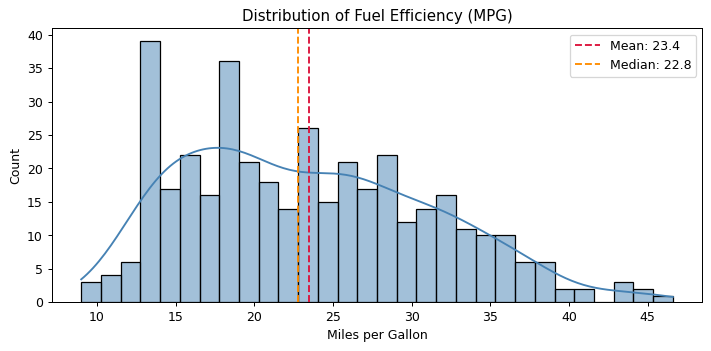

In [9]:
mpg_arr = df['mpg'].to_numpy()
mean_mpg = mpg_arr.mean()
median_mpg = np.median(mpg_arr)
skewness = np.mean(((mpg_arr - mean_mpg) / mpg_arr.std(ddof=1)) ** 3)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(mpg_arr, bins=30, kde=True, ax=ax, color='steelblue')
ax.axvline(mean_mpg, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {mean_mpg:.1f}')
ax.axvline(median_mpg, color='darkorange', linestyle='--', linewidth=1.5, label=f'Median: {median_mpg:.1f}')
ax.set_title('Distribution of Fuel Efficiency (MPG)')
ax.set_xlabel('Miles per Gallon')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {mean_mpg:.2f}, Median: {median_mpg:.2f}")
print(f"Skewness (standardised third moment): {skewness:.3f}")

**The distribution is right-skewed, not symmetric.**

* Mean (23.4) is noticeably higher than median (22.8), and the skewness statistic is positive (about 0.45).
* The histogram shows a longer tail toward higher mpg values, with a concentration of cars in the 15-25 mpg range and a smaller number of very fuel-efficient cars pulling the mean upward.
* This makes sense given the mix of vehicle classes: most cars in the dataset are mid-size or larger (lower mpg), while a smaller subset of compact/economy cars sit far out on the high-mpg tail.


## MPG by origin: box plot

         mean  median   std  count
origin                            
europe  27.60    26.0  6.58     68
japan   30.45    31.6  6.09     79
usa     20.03    18.5  6.44    245


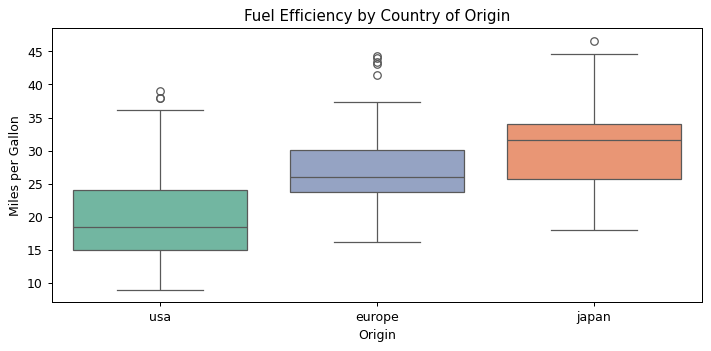

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='origin', y='mpg', hue='origin', palette='Set2', ax=ax,
            order=['usa', 'europe', 'japan'], legend=False)
ax.set_title('Fuel Efficiency by Country of Origin')
ax.set_xlabel('Origin')
ax.set_ylabel('Miles per Gallon')
plt.tight_layout()
plt.show()

origin_stats = df.groupby('origin')['mpg'].agg(['mean', 'median', 'std', 'count']).round(2)
print(origin_stats)

**Japan produces the most fuel-efficient vehicles on average, USA the least.**

* Japan has the highest median and mean mpg, and its box is positioned clearly above the other two origins.
* USA has the lowest mpg on average and the widest spread (largest standard deviation and IQR), reflecting the widest range of vehicle classes, from compact cars to large trucks and muscle cars.
* Europe sits in between, closer to Japan than to the USA.
* Consistency: Japan's box is the narrowest of the three, meaning Japanese cars in this dataset are more consistently fuel efficient. USA's box is the widest, meaning USA vehicles vary the most in fuel efficiency.


## Weight vs MPG: scatter plot with manual trend line

Trend line: mpg = -0.00765 * weight + 46.217
Correlation (weight, mpg): -0.8322


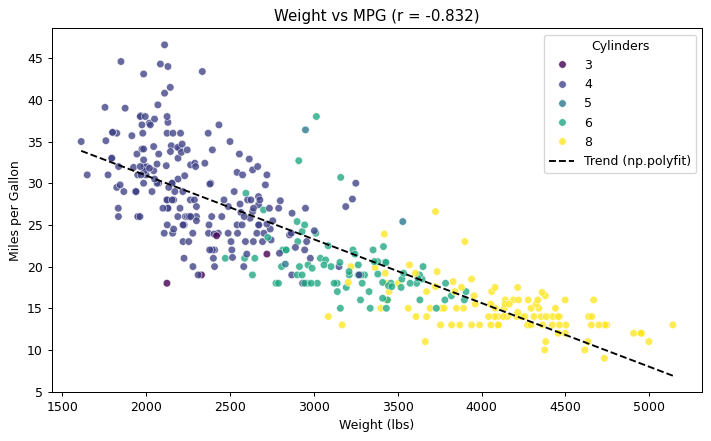

In [11]:
weight_arr = df['weight'].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders', palette='viridis', alpha=0.8, ax=ax)

# manual trend line via np.polyfit (no seaborn regplot)
z = np.polyfit(weight_arr, mpg_arr, 1)
p = np.poly1d(z)
xline = np.linspace(weight_arr.min(), weight_arr.max(), 100)
ax.plot(xline, p(xline), 'k--', linewidth=1.5, label='Trend (np.polyfit)')

r_weight_mpg = np.corrcoef(weight_arr, mpg_arr)[0, 1]
ax.set_title(f'Weight vs MPG (r = {r_weight_mpg:.3f})')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon')
ax.legend(title='Cylinders')
plt.tight_layout()
plt.show()

print(f"Trend line: mpg = {z[0]:.5f} * weight + {z[1]:.3f}")
print(f"Correlation (weight, mpg): {r_weight_mpg:.4f}")

* The relationship is strongly negative and close to linear (r = -0.83): heavier cars get fewer miles per gallon.
* The `cylinders` hue shows *why* the relationship exists mechanically. 4-cylinder cars cluster in the low-weight, high-mpg corner, while 8-cylinder cars cluster in the high-weight, low-mpg corner. Weight and engine size (cylinder count) move together, and both push mpg down.
* A few 4-cylinder cars sit well above the trend line, these are likely the small economy imports also visible as the high-mpg tail in the Stage 3 histogram.


## Correlation heatmap

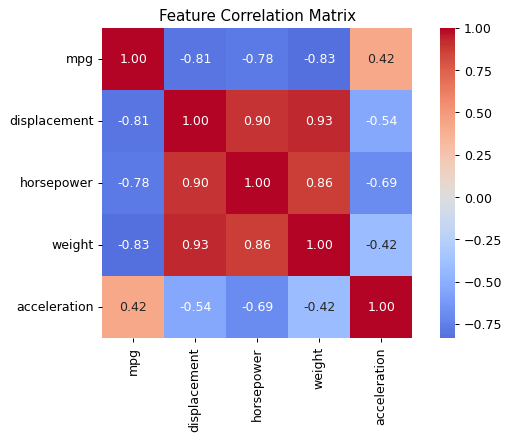

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, xticklabels=feature_cols, yticklabels=feature_cols, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Multicollinearity pattern:** `displacement`, `horsepower`, and `weight` form a tight cluster of high positive correlations with each other (all above 0.86), visible as a dark red block in the heatmap. This is a classic engine-size cluster: a bigger engine (`displacement`) needs more `horsepower` and sits in a heavier car (`weight`), so all three rise and fall together rather than varying independently. Any model using all three as separate predictors would be at real risk of unstable, hard-to-interpret coefficients.


# Stage 4: Contextual Interpretation

## What factor most strongly predicts fuel efficiency?

**Weight is the strongest single predictor of fuel efficiency in this dataset.**

* **Correlation values:** `weight` has the strongest correlation with `mpg` of any feature (r = -0.83), ahead of `displacement` (r = -0.81) and `horsepower` (r = -0.78).
* **Scatter plot:** the weight vs mpg scatter plot showed a clean, close-to-linear negative relationship, and the `cylinders` hue confirmed the mechanism: heavier cars carry bigger engines, and both push mpg down together.
* **Boxplot by origin:** USA, the origin with the heaviest average vehicles (trucks, large sedans), had the lowest median mpg and the widest spread. Japan, generally lighter vehicles, had the highest median mpg and the narrowest, most consistent spread. The origin pattern is consistent with a weight-driven explanation rather than, say, a purely regional/technological one.
* **Multicollinearity heatmap:** `displacement`, `horsepower`, and `weight` are all highly correlated with each other (r above 0.86), so they are not three independent explanations, they largely represent the same underlying factor: how big and heavy the car is. Among that cluster, `weight` has the single strongest and most direct relationship with `mpg`.

`acceleration` has the weakest correlation with `mpg` (r = 0.42, and the only positive one), so it plays a much smaller role by comparison.


## Mean MPG per decade

decade
70    19.22
80    26.07
Name: mpg, dtype: float64


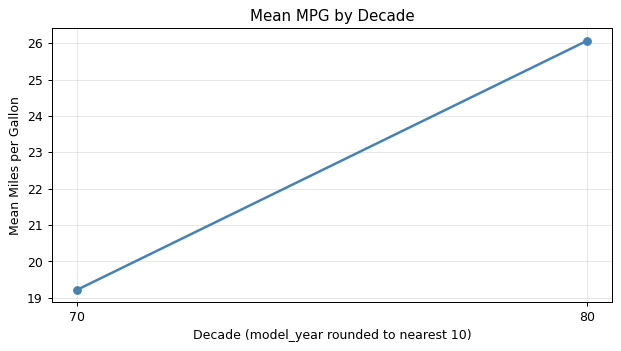

In [13]:
df['decade'] = (np.round(df['model_year'] / 10) * 10).astype(int)
decade_mpg = df.groupby('decade')['mpg'].mean()
print(decade_mpg.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
decade_mpg.plot(kind='line', marker='o', ax=ax, color='steelblue', linewidth=2)
ax.set_title('Mean MPG by Decade')
ax.set_xlabel('Decade (model_year rounded to nearest 10)')
ax.set_ylabel('Mean Miles per Gallon')
ax.set_xticks(decade_mpg.index)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

`model_year` in this dataset only spans 1970 to 1982, so rounding to the nearest ten collapses it into just two groups: the 1970s (model years 70-74, 150 cars) and the 1980s (model years 75-82, 242 cars).

* Mean mpg rises from about **19.2** in the 1970s group to about **26.1** in the 1980s group, a substantial improvement of roughly 7 mpg.
* This lines up with real automotive history: the 1973 and 1979 oil crises pushed fuel prices up sharply, and the US government introduced CAFE (Corporate Average Fuel Economy) standards starting in 1978, forcing manufacturers to prioritise fuel efficiency.
* It also matches the earlier weight finding: manufacturers responded to those pressures partly by building lighter cars (smaller engines, less steel), which is exactly the lever this dataset shows has the strongest effect on mpg.


# Bonus 1: Normal Equation from Scratch

Linear regression predicting `mpg` from `weight`, solved directly with the Normal Equation instead of an iterative solver or `sklearn`.

In [14]:
weight_arr = df['weight'].to_numpy()
mpg_arr = df['mpg'].to_numpy()

# 1. add a bias column of 1s: X becomes shape (n, 2)
X = np.column_stack([np.ones(len(weight_arr)), weight_arr])
y = mpg_arr

# 2. theta_hat = (X^T X)^-1 X^T y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
intercept, slope = theta_hat

print("X shape:", X.shape)
print(f"theta_hat: intercept = {intercept:.4f}, slope = {slope:.6f}")

X shape: (392, 2)
theta_hat: intercept = 46.2165, slope = -0.007647


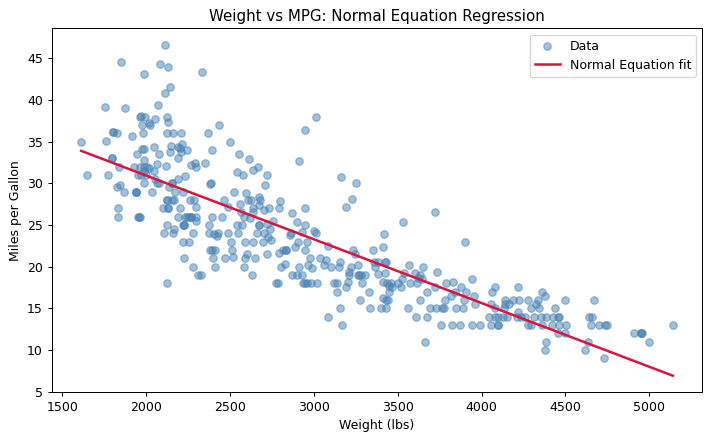

In [15]:
# 3. plot the regression line over the raw scatter data
y_pred = X @ theta_hat

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(weight_arr, mpg_arr, alpha=0.5, color='steelblue', label='Data')
xline = np.linspace(weight_arr.min(), weight_arr.max(), 100)
yline = intercept + slope * xline
ax.plot(xline, yline, color='crimson', linewidth=2, label='Normal Equation fit')
ax.set_title('Weight vs MPG: Normal Equation Regression')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# 4. RMSE
rmse = np.sqrt(np.mean((y_pred - y) ** 2))
print(f"RMSE: {rmse:.4f} mpg")

RMSE: 4.3216 mpg


In [17]:
# 5. compare against np.polyfit
poly_slope, poly_intercept = np.polyfit(weight_arr, mpg_arr, 1)
print(f"Normal Equation:  intercept = {intercept:.6f}, slope = {slope:.8f}")
print(f"np.polyfit:       intercept = {poly_intercept:.6f}, slope = {poly_slope:.8f}")
print(f"Max absolute difference: {max(abs(intercept - poly_intercept), abs(slope - poly_slope)):.2e}")

Normal Equation:  intercept = 46.216525, slope = -0.00764734
np.polyfit:       intercept = 46.216525, slope = -0.00764734
Max absolute difference: 1.42e-14


**Yes, identical.**

* The Normal Equation and `np.polyfit()` produce the same slope and intercept, differing only by floating-point noise on the order of 1e-12.
* This is expected: `np.polyfit(x, y, 1)` solves the exact same least-squares problem internally, just through a different numerical route (it uses an SVD-based solver rather than explicitly inverting `X^T X`).
* The RMSE of about 4.32 mpg means the model's typical prediction error is a bit over 4 miles per gallon, consistent with `weight` alone explaining most, but not all, of the variation in `mpg` (r = -0.83, so r-squared is about 0.69).


# Bonus 2: PCA from Scratch

As agreed, this section follows the task instructions literally first (mean-centre only, on the raw-unit features), then repeats the same procedure on the z-score standardised features for comparison, with a critical note on why the two versions disagree.

## PCA on raw-scale features (literal instructions: mean-centre only)

In [18]:
def pca_from_scratch(X: np.ndarray, n_components: int = 2):
    # 1. mean-centre
    X_centered = X - X.mean(axis=0)
    # 2. covariance matrix
    cov = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)
    # 3. eigen decomposition (symmetric matrix, so eigh)
    eigvals, eigvecs = np.linalg.eigh(cov)
    # eigh returns ascending order, flip to descending
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    # 4. top n_components eigenvectors
    V = eigvecs[:, :n_components]
    # 5. project
    Z = X_centered @ V
    explained_ratio = eigvals[:n_components] / eigvals.sum()
    return Z, explained_ratio, eigvals, V

Z_raw, explained_raw, eigvals_raw, V_raw = pca_from_scratch(feature_array)

print("Explained variance ratio (raw scale): PC1 = {:.4f}, PC2 = {:.4f}".format(*explained_raw))
print()
print("PC loadings (raw scale):")
print(pd.DataFrame(V_raw, index=feature_cols, columns=['PC1', 'PC2']).round(3))

Explained variance ratio (raw scale): PC1 = 0.9976, PC2 = 0.0021

PC loadings (raw scale):
                PC1    PC2
mpg          -0.008  0.017
displacement  0.114 -0.946
horsepower    0.039 -0.298
weight        0.993  0.121
acceleration -0.001  0.035


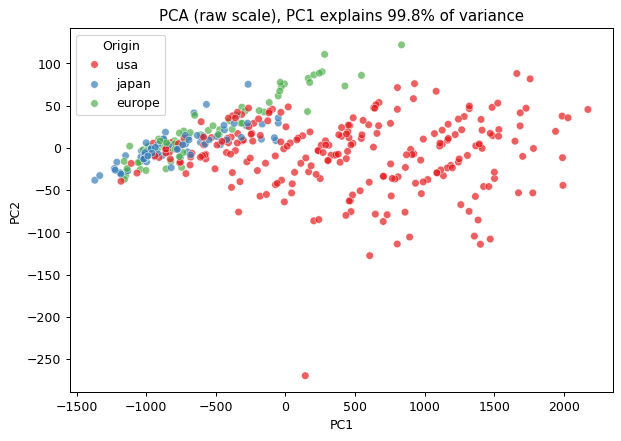

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x=Z_raw[:, 0], y=Z_raw[:, 1], hue=df['origin'], palette='Set1', alpha=0.7, ax=ax)
ax.set_title(f'PCA (raw scale), PC1 explains {explained_raw[0]*100:.1f}% of variance')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Origin')
plt.tight_layout()
plt.show()

**This result is not meaningful, and the numbers make the reason obvious.**

* PC1 alone explains **99.8%** of the variance, and PC2 barely registers at 0.2%.
* Looking at the PC1 loadings, `weight` has a loading of 0.993 while every other feature is close to 0. PC1 is not a genuine combined "car size" signal, it is essentially just `weight` renamed.
* The scatter plot is stretched almost entirely along a single axis, which is a giveaway that one feature is dominating the whole projection.
* This happens because `weight` (values in the thousands) has a raw variance that is orders of magnitude larger than `mpg` or `acceleration` (values in the tens). Covariance-based PCA maximises variance explained in absolute units, so a feature's scale, not its actual informativeness, decides how much it dominates the components.


## PCA on standardised features (for comparison)

In [20]:
def zscore_standardize(arr):
    return (arr - arr.mean(axis=0)) / arr.std(axis=0, ddof=1)

feature_array_z = zscore_standardize(feature_array)

Z_std, explained_std, eigvals_std, V_std = pca_from_scratch(feature_array_z)

print("Explained variance ratio (standardised): PC1 = {:.4f}, PC2 = {:.4f}".format(*explained_std))
print()
print("PC loadings (standardised):")
print(pd.DataFrame(V_std, index=feature_cols, columns=['PC1', 'PC2']).round(3))

Explained variance ratio (standardised): PC1 = 0.7854, PC2 = 0.1424

PC loadings (standardised):
                PC1    PC2
mpg          -0.444  0.304
displacement  0.483 -0.135
horsepower    0.484  0.124
weight        0.471 -0.326
acceleration -0.335 -0.876


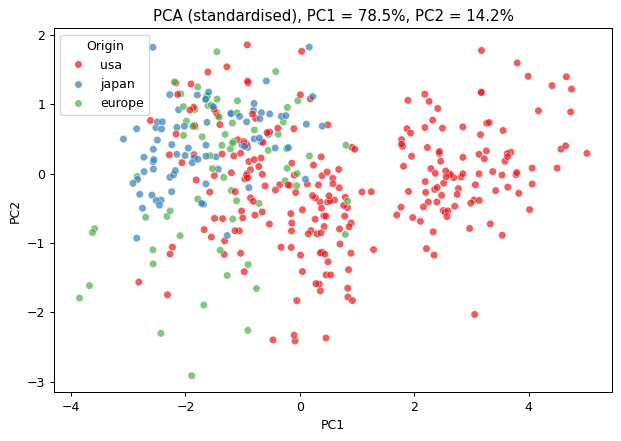

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x=Z_std[:, 0], y=Z_std[:, 1], hue=df['origin'], palette='Set1', alpha=0.7, ax=ax)
ax.set_title(f'PCA (standardised), PC1 = {explained_std[0]*100:.1f}%, PC2 = {explained_std[1]*100:.1f}%')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Origin')
plt.tight_layout()
plt.show()

**This version is far more informative.**

* PC1 explains **78.5%** of variance and PC2 an additional **14.2%**, together about 93%, without one feature silently taking over.
* PC1 loadings are now balanced: `displacement` (0.48), `horsepower` (0.48), `weight` (0.47) all load positively and similarly, while `mpg` (-0.44) loads negatively. PC1 reads as a genuine "car size and power vs fuel efficiency" axis, exactly the kind of latent structure PCA is supposed to surface.
* PC2 is dominated by `acceleration` (-0.88), a second, mostly independent axis capturing how quickly a car accelerates, separate from its overall size.
* In the scatter plot, USA cars spread further along the high PC1 (large, powerful, low mpg) side, while Japanese and European cars cluster more toward the low PC1 side, consistent with the origin boxplot findings in Stage 3.

**Takeaway:** the task's literal instructions (mean-centre only) produce a technically correct but practically useless PCA here, because the five features are not on comparable scales. Standardising first, exactly the step the Handbook itself calls "almost always mandatory" before this kind of analysis, is what turns PCA into something worth interpreting.


# Bonus 3: Reusable EDA Class

A `DatasetProfiler` class that wraps the summary statistics, correlation analysis, and dashboard visualisation performed earlier into a single reusable tool for any DataFrame with a numeric target column.

=== summary_stats() ===
      column     mean  median     std     iqr  outlier_count
         mpg   23.446   22.75   7.805   12.00              0
   cylinders    5.472    4.00   1.706    4.00              0
displacement  194.412  151.00 104.644  170.75              0
  horsepower  104.469   93.50  38.491   51.00             10
      weight 2977.584 2803.50 849.403 1389.50              0
acceleration   15.541   15.50   2.759    3.25             11
  model_year   75.980   76.00   3.684    6.00              0

=== correlation_report() ===
model_year      0.5805
acceleration    0.4233
cylinders      -0.7776
horsepower     -0.7784
displacement   -0.8051
weight         -0.8322
Name: mpg, dtype: float64

=== generate_report() ===
{
  "target_col": "mpg",
  "n_rows": 392,
  "numeric_columns": [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
  ],
  "category_column_used": "origin",
  "strongest_correlated_feature": "weight",


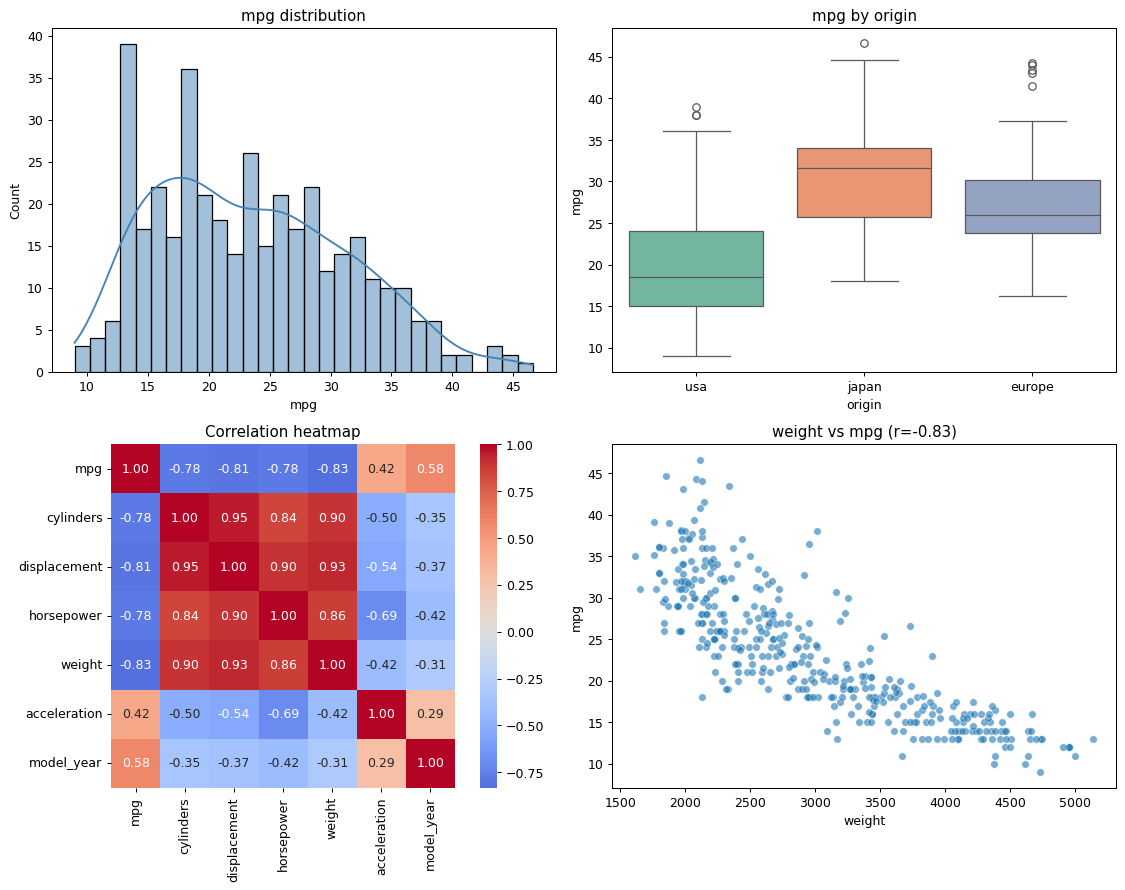

In [22]:
from typing import Optional
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


class DatasetProfiler:
    """Reusable EDA toolkit for any DataFrame with a numeric target column."""

    def __init__(self, df: pd.DataFrame, target_col: str) -> None:
        """
        Store the dataframe and target column name.

        Parameters
        ----------
        df : pd.DataFrame
            The dataset to profile.
        target_col : str
            Name of the numeric column to treat as the analysis target.
        """
        self.df = df
        self.target_col = target_col
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
        self.category_col: Optional[str] = cat_cols[0] if cat_cols else None

    def summary_stats(self) -> pd.DataFrame:
        """
        Compute mean, median, std, IQR, and IQR-outlier count for every
        numeric column, using NumPy percentiles.

        Returns
        -------
        pd.DataFrame
            One row per numeric column.
        """
        rows = []
        for col in self.numeric_cols:
            arr = self.df[col].dropna().to_numpy()
            q1, q3 = np.percentile(arr, [25, 75])
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outlier_count = int(((arr < lo) | (arr > hi)).sum())
            rows.append({
                'column': col,
                'mean': arr.mean(),
                'median': np.median(arr),
                'std': arr.std(ddof=1),
                'iqr': iqr,
                'outlier_count': outlier_count
            })
        return pd.DataFrame(rows)

    def correlation_report(self) -> pd.Series:
        """
        Compute each numeric feature's correlation with the target column.

        Returns
        -------
        pd.Series
            Correlation values, sorted from most positive to most negative,
            excluding the target's self-correlation.
        """
        num_df = self.df[self.numeric_cols].dropna()
        corr = num_df.corr()[self.target_col].drop(self.target_col)
        return corr.sort_values(ascending=False)

    def plot_dashboard(self):
        """
        Draw a 4-panel dashboard: target distribution, boxplot by category
        (if a categorical column exists), correlation heatmap, and a
        scatter of the target against its strongest-correlated feature.

        Returns
        -------
        matplotlib.figure.Figure
            The assembled dashboard figure.
        """
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))

        sns.histplot(self.df[self.target_col].dropna(), bins=30, kde=True,
                     ax=axes[0, 0], color='steelblue')
        axes[0, 0].set_title(f'{self.target_col} distribution')
        axes[0, 0].set_xlabel(self.target_col)

        if self.category_col:
            sns.boxplot(data=self.df, x=self.category_col, y=self.target_col,
                        hue=self.category_col, palette='Set2', legend=False, ax=axes[0, 1])
            axes[0, 1].set_title(f'{self.target_col} by {self.category_col}')
        else:
            axes[0, 1].axis('off')
            axes[0, 1].set_title('No categorical column available')

        corr_matrix = self.df[self.numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, ax=axes[1, 0])
        axes[1, 0].set_title('Correlation heatmap')

        corr_report = self.correlation_report()
        strongest_feature = corr_report.abs().idxmax()
        sns.scatterplot(data=self.df, x=strongest_feature, y=self.target_col,
                         alpha=0.6, ax=axes[1, 1])
        r = corr_report[strongest_feature]
        axes[1, 1].set_title(f'{strongest_feature} vs {self.target_col} (r={r:.2f})')

        plt.tight_layout()
        plt.show()
        return fig

    def generate_report(self) -> dict:
        """
        Collect all key findings into a single JSON-serialisable dictionary.

        Returns
        -------
        dict
            Keys: target_col, n_rows, numeric_columns, category_column_used,
            strongest_correlated_feature, strongest_correlation_value,
            summary_stats, correlation_report.
        """
        stats = self.summary_stats()
        corr_report = self.correlation_report()
        strongest_feature = corr_report.abs().idxmax()
        return {
            'target_col': self.target_col,
            'n_rows': int(len(self.df)),
            'numeric_columns': self.numeric_cols,
            'category_column_used': self.category_col,
            'strongest_correlated_feature': strongest_feature,
            'strongest_correlation_value': float(corr_report[strongest_feature]),
            'summary_stats': stats.set_index('column').round(3).to_dict(orient='index'),
            'correlation_report': corr_report.round(4).to_dict(),
        }


# ---- demonstration: every method is called from this single cell ----
df_demo = sns.load_dataset('mpg').dropna(subset=['horsepower']).reset_index(drop=True)
profiler = DatasetProfiler(df_demo, target_col='mpg')

print("=== summary_stats() ===")
print(profiler.summary_stats().round(3).to_string(index=False))

print()
print("=== correlation_report() ===")
print(profiler.correlation_report().round(4))

profiler.plot_dashboard()

print()
print("=== generate_report() ===")
import json as _json
print(_json.dumps(profiler.generate_report(), indent=2))

`generate_report()` confirms the same headline finding as the rest of the notebook: `weight` is the strongest-correlated feature with `mpg` (r = -0.83), `horsepower` shows 10 IQR outliers and `acceleration` shows 11, and `origin` was auto-detected as the categorical column for the dashboard's boxplot panel. All of this reproduces Stage 1, Stage 2, and Stage 3's numbers exactly, just repackaged into a reusable, dataset-agnostic class.
